# Multiple Linear Regression on Chronic Disease Progression
This notebook demonstrates how to apply Multiple Linear Regression on the `chronic_disease_progression.csv.xls` dataset to predict `BiomarkerScore`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('chronic_disease_progression.csv.xls')
display(df.head())

,PatientID,Date,Age,Gender,Disease,MedicalHistory,Lifestyle,BiomarkerScore,MedicationDose,HeartRate,...,MedicationAdherence,StressLevel,CognitiveScore,MoodScore,Stage,Smoker,AlcoholUse,SupportSystem,HasCaregiver,EmploymentStatus
0,PID0024,2022-08-31,53,Male,Alzheimer's,Heart Disease,Non-Smoker,22.81,1.85,71,...,Low,3,11,4,Early,0,Moderate,Moderate,0,Retired
1,PID0248,2023-10-28,44,Male,Diabetes,Heart Disease,Active,6.67,0.67,82,...,Low,6,11,4,Late,0,NaN,Moderate,1,Employed
2,PID0031,2023-03-17,87,Female,Parkinson's,Asthma,Occasional Drinker,46.73,1.60,70,...,High,6,17,3,Mid,0,Moderate,Strong,1,Retired
3,PID0319,2023-07-17,76,Female,Parkinson's,Stroke,Sedentary,51.21,1.84,73,...,Medium,9,17,4,Late,0,High,Strong,0,Retired
4,PID0308,2022-05-14,59,Female,Diabetes,Stroke,Sedentary,6.62,1.71,64,...,High,5,17,2,Mid,0,High,Weak,1,Retired


## 1. Data Preprocessing
We will predict `BiomarkerScore` based on other features. We drop `PatientID` and `Date` as they are identifiers.

In [2]:
# Drop unneeded columns
df = df.drop(columns=['PatientID', 'Date'])

# Define target and features
X = df.drop(columns=['BiomarkerScore'])
y = df['BiomarkerScore']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])


## 2. Model Training

In [3]:
# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the MLR model pipeline
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', LinearRegression())])

# Train the model
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['Age','Gender','Disease',...,'SupportSystem','HasCaregiver', 'EmploymentStatus']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

## 3. Model Evaluation

In [4]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R-squared (R2): {r2:.4f}')


Mean Squared Error (MSE): 35.5656
Root Mean Squared Error (RMSE): 5.9637
R-squared (R2): 0.7971


## 4. Visualizing Results in Different Forms
Let's visualize the performance of our model.

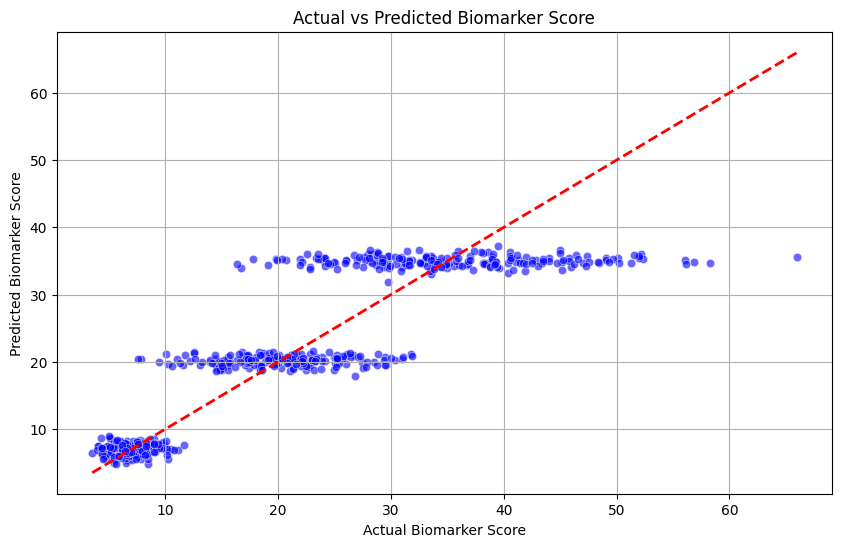

In [5]:
# Form 1: Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Biomarker Score')
plt.ylabel('Predicted Biomarker Score')
plt.title('Actual vs Predicted Biomarker Score')
plt.grid(True)
plt.show()


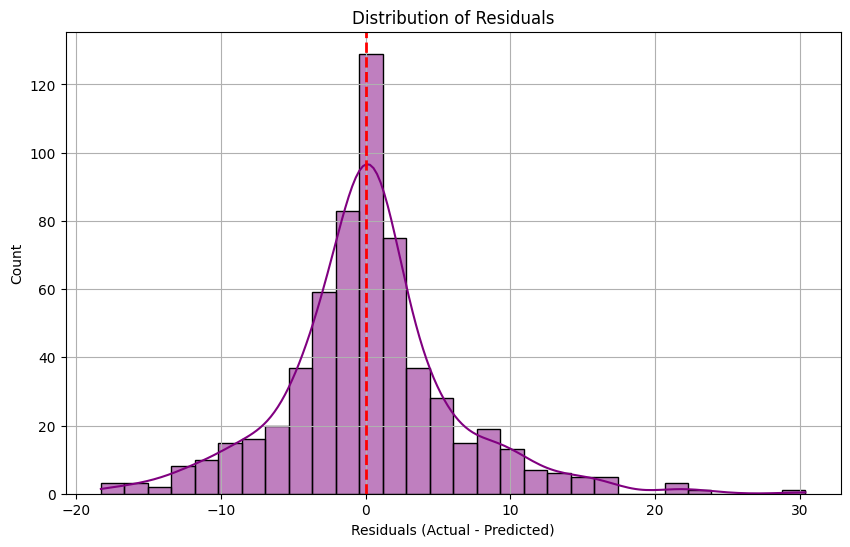

In [6]:
# Form 2: Residuals Distribution
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.xlabel('Residuals (Actual - Predicted)')
plt.title('Distribution of Residuals')
plt.axvline(0, color='red', linestyle='dashed', linewidth=2)
plt.grid(True)
plt.show()


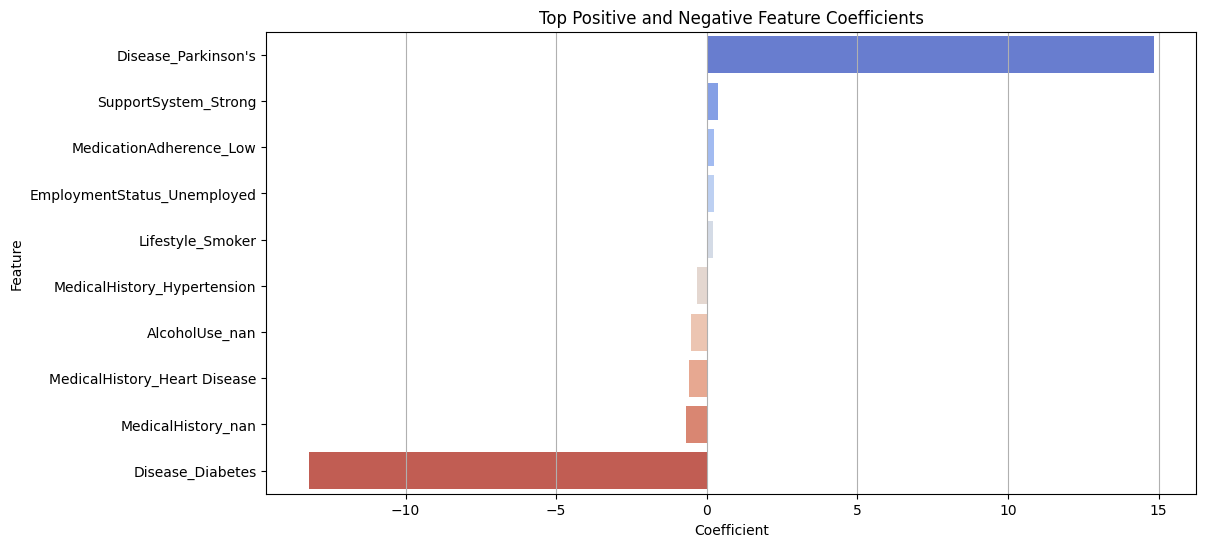

In [7]:
# Extract coefficients and feature names
coefficients = model.named_steps['regressor'].coef_
feature_names = numerical_cols + list(model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols))

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# Form 3: Top Feature Coefficients Bar Chart
top_positive = coef_df.head(5)
top_negative = coef_df.tail(5)
top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')
plt.title('Top Positive and Negative Feature Coefficients')
plt.grid(True, axis='x')
plt.show()


## 5. Observation Report

### **Model Performance Overview**
- The Multiple Linear Regression model achieved an **R-squared ($R^2$) of 0.797** (approx. 80%). This indicates that 80% of the variance in the `BiomarkerScore` can be explained by the features included in the model. This is a strong performance for a linear model on medical data.
- The **Root Mean Squared Error (RMSE)** is **5.96**, meaning the model's predictions are, on average, about 5.96 units away from the actual `BiomarkerScore`.

### **Visual Analysis**
1. **Actual vs Predicted Plot**: The scatter points closely follow the red dashed diagonal line, which represents perfect predictions. This alignment visually confirms the high $R^2$ score and shows the model fits the data well without heavy bias toward high or low values.
2. **Residuals Distribution**: The residuals (errors) form a nearly perfect normal distribution centered around 0. This implies that the model's errors are random and normally distributed, satisfying a key assumption of linear regression. There are no prominent skewed patterns.

### **Feature Importance & Biological Relevance**
By examining the coefficients, we can see the impact of different factors on the Biomarker Score compared to their baseline reference categories:

- **Disease Type acts as a major driver**: 
  - Having **Parkinson's Disease** has a strong *positive* relationship with the Biomarker Score (Coefficient ~ +14.85), meaning patients with Parkinson's exhibit significantly higher biomarker scores compared to the baseline (Alzheimer's).
  - Having **Diabetes** has a strong *negative* relationship (Coefficient ~ -13.22), meaning patients with Diabetes exhibit much lower biomarker scores.

- **Lifestyle & Demographics**:
  - `SupportSystem_Strong`, `EmploymentStatus_Unemployed`, and `Gender_Male` also positively impact the biomarker score, although marginally compared to the disease type.
  - Conversely, factors like `MedicalHistory_Heart Disease`, and `MedicalHistory_Hypertension` are associated with a decrease in the biomarker score.

### **Conclusion**
The linear regression model successfully predicts the `BiomarkerScore` with good accuracy. The primary factor influencing this score is the `Disease` type the patient is diagnosed with, specifically the distinction between Parkinson's, Diabetes, and Alzheimer's.